In [6]:
from src.model.baseline import Config
import torch

In [7]:
from src.datasets import Flickr8k
data_path = '../data/flickr8k'
data = Flickr8k(data_path)
data_dict = data.load_caption()


Data đã tồn tại


In [8]:
from preprocessing.preprocess import get_loaders

train_loader, val_loader, test_loader, vocab = get_loaders(Config, data_dict)

Vocabulary built! Size: 5231 words (Threshold: 2)
Data Split: Train=5663, Val=825, Test=1603 images


In [9]:
imgs, captions = next(iter(train_loader))
print(f"Images Shape: {imgs.shape}")
print(f"Captions Shape: {captions.shape}")

Images Shape: torch.Size([32, 3, 224, 224])
Captions Shape: torch.Size([32, 17])


In [10]:
sample_cap = captions[0]
print(f"Tensor: {sample_cap}")
print(f"Decoded: {vocab.denumericalize(sample_cap)}")

Tensor: tensor([  1,   4,  76, 102, 591, 159, 111,   4, 672, 193,   2,   0,   0,   0,
          0,   0,   0])
Decoded: a man wearing no shirt climbs a steep cliff


In [11]:
from src.model.baseline import CNNtoRNN

# Tạo dữ liệu giả
dummy_img = torch.randn(4, 3, 224, 224).to(Config.DEVICE) # Batch 4 ảnh
dummy_captions = torch.randint(0, 100, (4, 15)).to(Config.DEVICE) # Batch 4 câu, dài 15
# 2. Khởi tạo model
model = CNNtoRNN(
    embed_size=Config.EMBED_SIZE,
    hidden_size=Config.HIDDEN_SIZE,
    vocab_size=3000,
    num_layers=Config.NUM_LAYERS,
    train_cnn=Config.TRAIN_CNN,
    dropout=Config.DROPOUT
).to(Config.DEVICE)

# 3. Chạy thử Forward Pass
print("Running forward pass...")
outputs = model(dummy_img, dummy_captions)

print(f"Input Image: {dummy_img.shape}")
print(f"Input Caption: {dummy_captions.shape}")
print(f"Output Logits: {outputs.shape}")

# Kiểm tra kích thước output
expected_shape = (4, 14, 3000)

if outputs.shape == expected_shape:
    print("MODEL SHAPE MATCH! Ready for training.")
else:
    print(f"SHAPE MISMATCH! Expected {expected_shape}, got {outputs.shape}")

Input Image: torch.Size([4, 3, 224, 224])
Input Caption: torch.Size([4, 15])
Output Logits: torch.Size([4, 14, 3000])
MODEL SHAPE MATCH! Ready for training.


In [12]:
from model.train import run_training

run_training(train_loader, val_loader, test_loader, vocab)

	>>> Demo Caption: a man in a red shirt is standing on a red

HOÀN TẤT HUẤN LUYỆN!


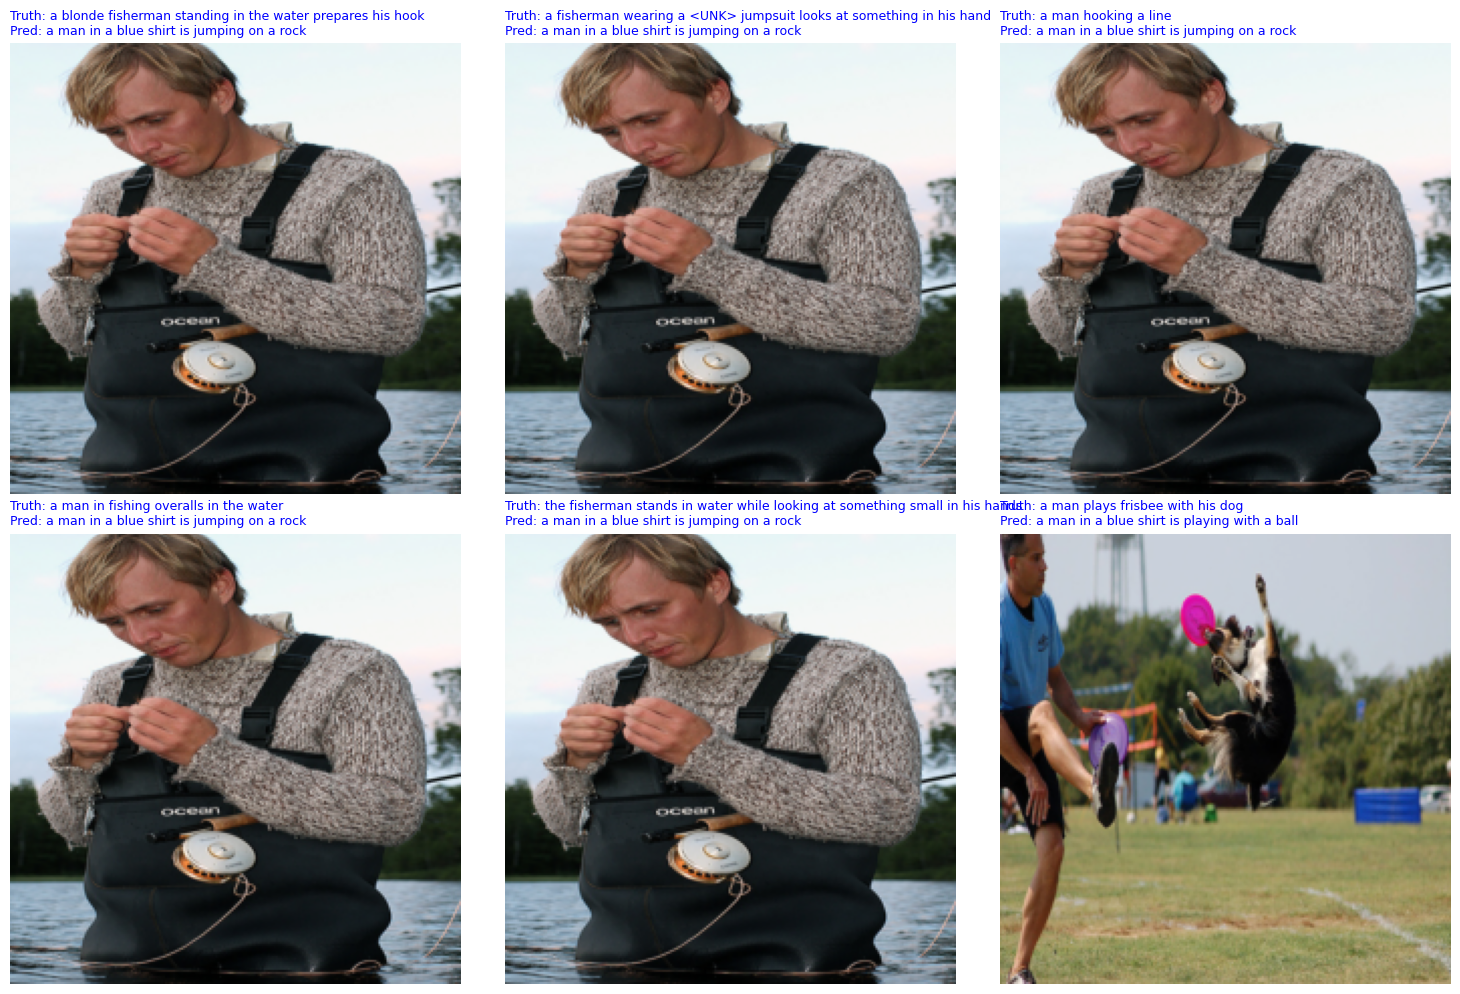

In [16]:
from src.model import Evaluator
from src.model.baseline import CNNtoRNN

# 1. Load lại model tốt nhất
checkpoint_path = r"D:\Github\image-captioning-mini\notebooks\checkpoints\bs32_lr0.0003_emb256_20260127_2202.pth"
checkpoint = torch.load(
    checkpoint_path,
    map_location=Config.DEVICE,
    weights_only=False
)

# 2. Khởi tạo lại kiến trúc model
model = CNNtoRNN(
    embed_size=Config.EMBED_SIZE,
    hidden_size=Config.HIDDEN_SIZE,
    vocab_size=len(vocab),
    num_layers=Config.NUM_LAYERS,
    train_cnn=Config.TRAIN_CNN,
    dropout=Config.DROPOUT
).to(Config.DEVICE)

# 3. Load trọng số (Weights)
model.load_state_dict(checkpoint['state_dict'])
print("✅ Model loaded successfully!")

# --- BẮT ĐẦU ĐÁNH GIÁ ---
evaluator = Evaluator(model, vocab, Config.DEVICE)

# Bước 1: Tính điểm số
evaluator.calculate_metrics(test_loader)

# Bước 2: Xem ảnh minh họa (Validation/Test)
evaluator.visualize(test_loader)

# Bước 3: Thử với ảnh ngoài
# evaluator.predict_image("test_image.jpg")